# Finland Nuclear Power Generation — 15-Minute Data (2023–2025)

Downloads Finland nuclear power production (MW) from the **Fingrid Open Data API**
and resamples it to 15-minute resolution.

- Source: Fingrid dataset "Nuclear power production" (real-time, ~3 min)
- Range: 2023-01-01 → 2025-12-31
- Requires a free Fingrid API key via the `FINGRID_API_KEY` environment variable.
- Output: `nuclear_measured_15min.csv` (in this folder, `data/originalData/Nuclear/`)

> Sign: positive = generation (MW). This is the **measured** (realized) nuclear
> output — for the price model it can only be used as **lag/rolling features**
> (the current-period value is not known at live forecast time).


In [1]:
import os
import time
import pandas as pd
import requests

In [ ]:
import os
from pathlib import Path

# ============================================================
# 读取 API key：从 notebook 同目录的 .env 文件读取
# .env 已被 .gitignore 忽略 → 提交到 GitHub 时不会包含 key
# ============================================================

env_file = Path('.env')  # Jupyter 的工作目录就是 notebook 所在目录
if env_file.exists():
    for line in env_file.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if line.startswith('FINGRID_API_KEY='):
            os.environ['FINGRID_API_KEY'] = line.split('=', 1)[1].strip()

API_KEY = os.environ.get('FINGRID_API_KEY')
if not API_KEY:
    raise EnvironmentError(
        'FINGRID_API_KEY 未设置。\n'
        '请在 notebook 同目录创建 .env 文件：\n'
        '  FINGRID_API_KEY=你的key'
    )

print('FINGRID_API_KEY loaded:', 'yes' if API_KEY else 'no')

FINGRID_API_KEY loaded: yes


### 1. Discover the nuclear dataset ID

Search the Fingrid catalog to confirm which dataset ID is "Nuclear power production".
The real-time dataset is usually ID 188 — verify here before fetching.


In [8]:
# Query the Fingrid catalog and print nuclear-related datasets.
resp = requests.get(
    'https://data.fingrid.fi/api/datasets',
    headers={'x-api-key': API_KEY},
    params={'pageSize': 500},
    timeout=30,
)
resp.raise_for_status()
catalog = resp.json().get('data', [])
print(f'Total datasets in catalog: {len(catalog)}\n')

print('--- Nuclear related datasets ---')
for ds in catalog:
    name_en = (ds.get('nameEn') or '').lower()
    if 'nuclear' in name_en:
        print(f"  ID {ds['id']:>5}  {ds.get('nameEn', '')}")


Total datasets in catalog: 249

--- Nuclear related datasets ---
  ID   188  Nuclear power production - real-time data


### 2. Fetch function (paging + 429 retry)

Same pattern as `15min_GridTransmission.ipynb`.


In [9]:
def fetch_fingrid(dataset_id: int, start: str, end: str, api_key: str) -> pd.DataFrame:
    """Fetch all pages of one Fingrid dataset, returning a value Series in Helsinki time."""
    url = f'https://data.fingrid.fi/api/datasets/{dataset_id}/data'
    headers = {'x-api-key': api_key}
    all_rows = []
    page = 1
    while True:
        for attempt in range(5):
            resp = requests.get(url, headers=headers, params={
                'startTime': start,
                'endTime':   end,
                'format':    'json',
                'pageSize':  10000,
                'page':      page,
            }, timeout=60)
            if resp.status_code == 429:
                wait = 60 * (attempt + 1)
                print(f'  429 rate limit — waiting {wait}s before retry {attempt + 1}/5 ...')
                time.sleep(wait)
                continue
            resp.raise_for_status()
            break
        else:
            raise RuntimeError(f'Dataset {dataset_id} page {page}: still 429 after 5 retries')

        body = resp.json()
        rows = body.get('data', [])
        all_rows.extend(rows)
        print(f'  page {page}: {len(rows)} rows (total so far: {len(all_rows)})')
        if len(rows) < 10000:
            break
        page += 1
        time.sleep(2)   # 2s between pages to stay under the rate limit

    if not all_rows:
        return pd.DataFrame()
    df = pd.DataFrame(all_rows)
    df['datetime'] = pd.to_datetime(df['startTime'], utc=True).dt.tz_convert('Europe/Helsinki')
    df = df.set_index('datetime')[['value']]
    df = df.sort_index()
    return df


### 3. Fetch nuclear production 2023–2025

`NUCLEAR_DATASET` = the ID found in the discovery cell (real-time nuclear = 188).
The real-time series is ~3-minute resolution; we resample to 15 minutes (mean).

> If the fetched range does NOT cover 2023-2025 (real-time datasets sometimes keep
> limited history), stop and switch to ENTSO-E "Actual Generation per Production
> Type" (nuclear) which has full history from 2015.


In [10]:
NUCLEAR_DATASET = 188   # "Nuclear power production - real-time data" (verify above)
START = '2023-01-01T00:00:00Z'
END   = '2025-12-31T23:59:59Z'
HELSINKI = 'Europe/Helsinki'

raw = fetch_fingrid(NUCLEAR_DATASET, START, END, API_KEY)
print('\nRaw shape:', raw.shape)
if not raw.empty:
    print('Resolution:', raw.index.to_series().diff().mode()[0])
    print('Range     :', raw.index.min(), '->', raw.index.max())
    print('NaNs      :', raw['value'].isna().sum())


  429 rate limit — waiting 60s before retry 1/5 ...
  page 1: 10000 rows (total so far: 10000)
  page 2: 10000 rows (total so far: 20000)
  page 3: 10000 rows (total so far: 30000)
  page 4: 10000 rows (total so far: 40000)
  page 5: 10000 rows (total so far: 50000)
  page 6: 10000 rows (total so far: 60000)
  page 7: 10000 rows (total so far: 70000)
  page 8: 10000 rows (total so far: 80000)
  page 9: 10000 rows (total so far: 90000)
  page 10: 10000 rows (total so far: 100000)
  page 11: 10000 rows (total so far: 110000)
  page 12: 10000 rows (total so far: 120000)
  page 13: 10000 rows (total so far: 130000)
  page 14: 10000 rows (total so far: 140000)
  page 15: 10000 rows (total so far: 150000)
  page 16: 10000 rows (total so far: 160000)
  page 17: 10000 rows (total so far: 170000)
  page 18: 10000 rows (total so far: 180000)
  page 19: 10000 rows (total so far: 190000)
  page 20: 10000 rows (total so far: 200000)
  page 21: 10000 rows (total so far: 210000)
  page 22: 10000 rows

### 4. Resample to 15 min + sanity + save


Expected 15-min slots: 105216
Observed 15-min rows : 105216
Coverage on expected grid: 99.8%
Range: 2023-01-01 02:00:00+02:00 -> 2026-01-01 01:45:00+02:00
Stats: mean=3611 MW  min=1522  max=4409
NaN rows: 250


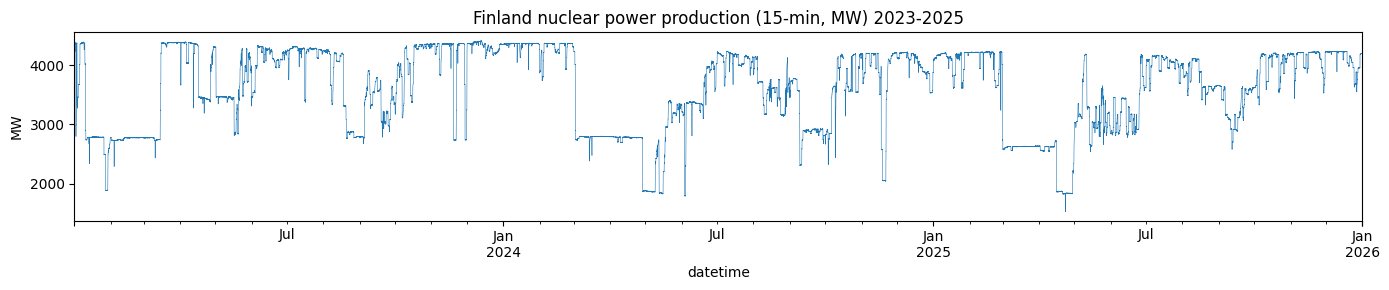


Saved → nuclear_measured_15min.csv


In [11]:
if raw.empty:
    raise RuntimeError('No nuclear data returned — check dataset ID / coverage.')

# resample ~3-min real-time -> 15-min mean (matches the 15-min price data)
nuclear_15 = raw['value'].resample('15min').mean()
nuclear_15 = nuclear_15[~nuclear_15.index.duplicated(keep='last')]

# coverage check
expected = pd.date_range('2023-01-01', '2025-12-31 23:45', freq='15min', tz=HELSINKI)
coverage = nuclear_15.reindex(expected).notna().mean()
print(f'Expected 15-min slots: {len(expected)}')
print(f'Observed 15-min rows : {len(nuclear_15)}')
print(f'Coverage on expected grid: {coverage:.1%}')
print(f'Range: {nuclear_15.index.min()} -> {nuclear_15.index.max()}')
print(f'Stats: mean={nuclear_15.mean():.0f} MW  min={nuclear_15.min():.0f}  max={nuclear_15.max():.0f}')
print(f'NaN rows: {nuclear_15.isna().sum()}')

# quick sanity plot
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 3))
nuclear_15.plot(linewidth=0.4)
plt.title('Finland nuclear power production (15-min, MW) 2023-2025')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

# save raw 15-min dataset into this folder (originalData/Nuclear/)
nuclear_15.rename('nuclear_power_mw').to_csv('nuclear_measured_15min.csv')
print('\nSaved → nuclear_measured_15min.csv')
